This notebook is the first of 2 notebooks that was used to test the eBEER model code against the example systems provided in Engel et al. 2020 (https://ui.adsabs.harvard.edu/abs/2020MNRAS.497.4884E/abstract).

This notebook does so by working directly with the Kepler Data for these systems. 

Alternatively the second such notebook tests against these systems using PHOEBE. For more details refer to the second notebook, "PaperSystemsTesting2.ipynb"


We start by importing the necessary packages:
 - numpy, pandas, matplotlib
 - phoebe
 - astropy.units - used to ensure PHOEBE understand what units we are working with
 - lightkurve - to retrieve Kepler Data
 - scipy.linalg.lstsq - used in detrending
 - scipy.optimize.curve_fit - for fitting
 - testing_utils - a .py file with some general tools for constructing and printing PHOEBE binaries
 - phoebe_to_ebeer - .py file containing model code to take a phoebe binary and return eBEER model light curve

In [33]:
import phoebe
import lightkurve as lk

import sys
sys.path.insert(1, '../scripts')
from phoebe_to_ebeer import get_ebeer_lc, get_ebeer_inputs, beaming, reflection, ellipticity
from binary_parameters import BinaryParams
import testing_utils as utils

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from astropy import units as u

from scipy.linalg import lstsq
from scipy.optimize import curve_fit


# System Parameters
We store all the parameters for the example sysems in the paper. They independently fit for these parameters with the eBEER model and PHOEBE. We store the parameters as a list of dataframes, where each dataframe refers to one system and contains 2 columns, the eBEER and PHOEBE fit parameters. This notebook will only work with the first column.

Metallicity, Linear Limb Darkening Coefficients, and Gravity Darkening Coefficients were found using MAST data and ExoCTK calculations with Kepler as the passband and the Phoeix ACES atmosphere model (unless otherwise noted)

In [34]:
systems = ('KIC6292925', 'KIC5200778', 'KIC4931390')

KIC6292925 = {
    "Fitted Model": ['eBEER', 'PHOEBE'],
    "Porb": [13.6126, 13.6122],
    "t0_perpass": [874.04, 875.977],
    "M1": [1.9, 1.89],
    "M2": [0.50, 0.50],
    "R1": [1.8, 1.80],
    "R2": [1.3, 1.10],
    "T1": [8300, 8400],
    "T2": [6000, 7000],
    "incl": [71, 72],
    "per0": [157, 153],
    "ecc": [0.232, 0.2491],
    "metallicity": [0.087, 0.087],
    # Had to use Kurucz ATLAS9 Model as the Phoenix ACES model doesnt cover
    # Teff range
    "u1": [0.622, 0.606],
    "u2": [0.741, 0.616],
}

KIC5200778 = {
    "Fitted Model": ['eBEER', 'PHOEBE'],
    "Porb": [16.357, 16.3536],
    "t0_perpass": [806.6, 804.2],
    "M1": [1.2, 1.20],
    "M2": [0.40, 0.37],
    "R1": [2.4, 2.30],
    "R2": [0.14, 0.47],
    "T1": [6000, 6500],
    "T2": [4000, 3500],
    "incl": [23, 24],
    "per0": [-1, 2],
    "ecc": [0.35, 0.26],
    "metallicity": [None,None], # Not available in MAST table so defaulting to 0
    "u1": [0.741, 0.687],
    "u2": [0.577, 0.774],
}

KIC4931390 = {
    "Fitted Model": ['eBEER', 'PHOEBE'],
    "Porb": [7.6064, 7.6080],
    "t0_perpass": [798.44, 794.78],
    "M1": [1.20, 1.10],
    "M2": [0.10, 0.13],
    "R1": [1.48, 1.42],
    "R2": [0.7, 0.66],
    "T1": [6500, 6620],
    "T2": [5500, 6500],
    "incl": [50, 35],
    "per0": [158, 160],
    "ecc": [0.08, 0.040],
    "metallicity": [-0.313, -0.313],
    "u1": [0.695, 0.693],
    "u2": [0.736, 0.695],
}

dfs = (KIC6292925, KIC5200778, KIC4931390)

Then we define a function to construct the phoebe binary for one of the above systems.

In [35]:
def grab_fit_params(df, idx):
    cur_fit_params = df.loc[idx]
    fit_type = cur_fit_params.pop('Fitted Model')
    pb = utils.get_phoebe_binary(**cur_fit_params)
    pb.add_dataset('lc', times=phoebe.linspace(0,1,101), dataset='lc01')
    return fit_type, pb

# Select System
Here we select which system we want to work with and then construct all necessary objects for testing.

First we select a system by modifying $i$: (0 = KIC6292925, 1 = KIC5200778, 2 = KIC4931390). Then the following cell will construct a phoebe_binary_ for this system as well as a eBEERParams object which we use to quickly grab parameters like the Porb of the system as necessary. For more details on the eBEERParams object see my code in "..\scripts\phoebe_to_ebeer.py".

We want fit_type_ to be eBEER for this notebook.

In [36]:
i = 0
target_name = systems[i]
df = pd.DataFrame(dfs[i])
fit_type_, phoebe_binary_ = grab_fit_params(df, 0)
binary_params = BinaryParams(from_phoebe=phoebe_binary_)

print(target_name, fit_type_)
utils.print_pb_params(phoebe_binary_)

KIC6292925 eBEER
Orbit - e: 0.232,  i: 71.0,  $\omega$: 157.0,  Porb: 13.6126,  t0_periastron: 874.04,  q: 0.2631578947368421
Star 1 - M1: 1.9,  R1: 1.8,  T1: 8300.0,  Prot1: 13.6126,  Limb Dark. Coeff: [0.622],  Grav Dark. Coeff: 0.32
Star 2 - M2: 0.5,  R2: 1.3,  T2: 6000.0,  Prot2: 13.6126,  Limb Dark. Coeff: [0.741],  Grav Dark. Coeff: 0.32


# Detrending

We start by defining the functions we will need for detrending following.

four_sigma_clip removes outliers by calculating a running median and rms of 31 measurements around each point and removing points that differed by $4\sigma$ or more from the median. This follows Mazeh 2013 (https://ui.adsabs.harvard.edu/abs/2012A%26A...541A..56M/abstract)

cosine_transform_detrending removes long term trends in the Kepler Data following Mazeh & Faigler 2010 (https://www.aanda.org/articles/aa/full_html/2010/13/aa15550-10/aa15550-10.html). To get acceptable results with our simpler testing code we remove frequencies up to the orbital frequency of the system.

In [37]:
def four_sigma_clip(time, flux, sigma=4):
    medians = np.zeros(len(flux))
    rmss = np.zeros(len(flux))
    for i in range(len(flux)):
        window = flux[max(0, i - 15) : min(len(flux), i + 15 + 1)]
        window = np.asarray(window)
        median = np.median(window)
        rms = np.sqrt(np.mean((window - median)**2))
        medians[i] = median
        rmss[i] = rms
    
    mask = np.abs(flux - medians) <= sigma * rmss
    return time[mask], flux[mask]
    

def cosine_transform_detrending(time, flux, Porb):
    T = time[-1] - time[0]
    N = round((2 * T) / (Porb))
    print(N)

    def cosine_basis(t, i):
        return np.cos((2 * np.pi / (2 * T)) * i * t)
    # Create the design matrix using the cosine basis functions
    A = np.array([cosine_basis(time, i) for i in range(0, N+1)]).T
    # Solve for the linear coefficients using least squares
    coeffs, _, _, _ = lstsq(A, flux)
    # Calculate the model flux
    model_flux = np.dot(A, coeffs)
    # Subtract the model from the original flux to get the detrended flux
    detrended_flux_lalg = flux - model_flux
    
    return detrended_flux_lalg, model_flux

Now we actually run detrending. The detrending here is in no way ideal, but it works to make sure we can replicate the general shape and scale of the lightcurves in testing. 

Detrending can struggle with certain Kepler Data quarters, so you may need to test various quarters to find some that work. These are quarters that have worked for me:
 - KIC6292925 - Q16
 - KIC5200778 - Q8
 - KIC4931390 - Q8

13


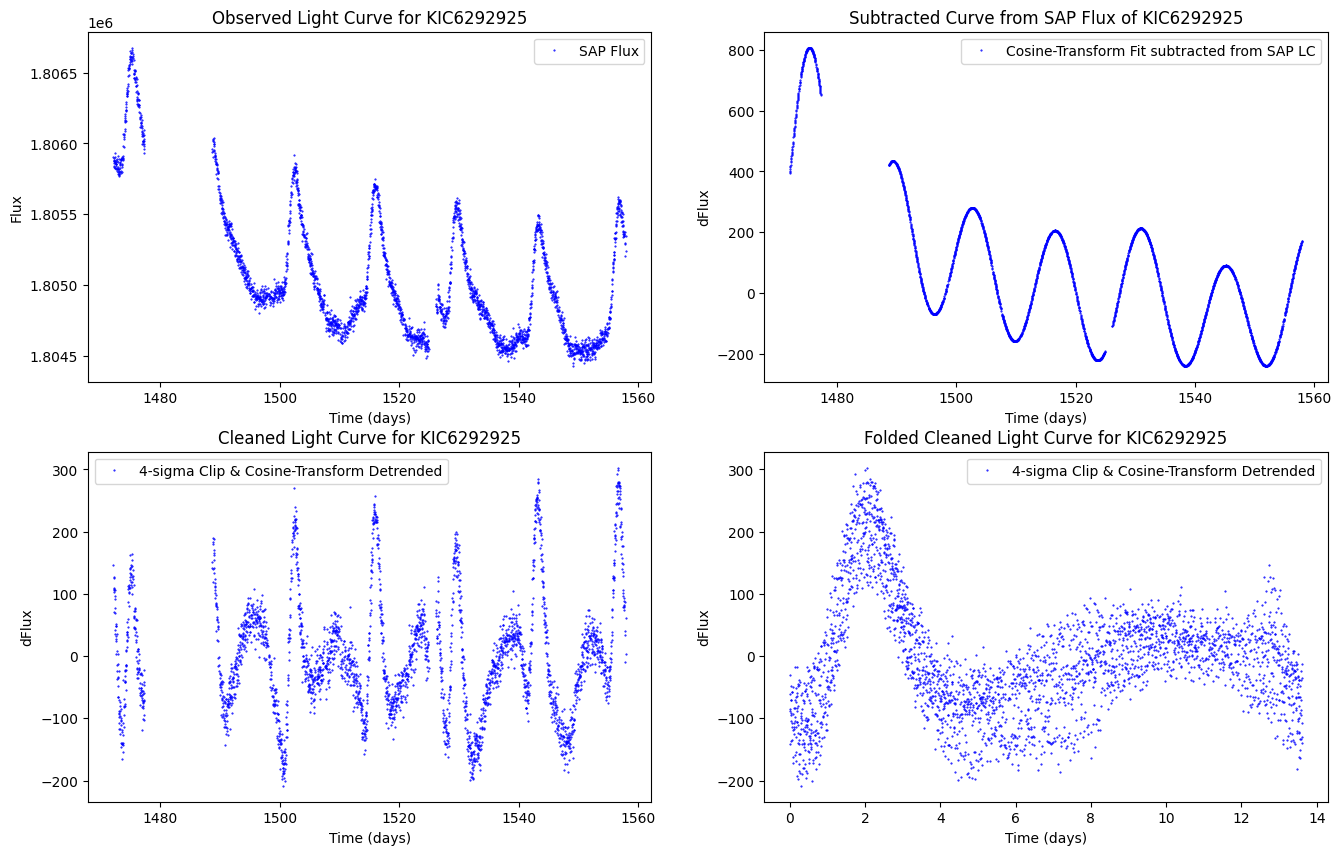

In [60]:
# Search and download light curve files
quarter = 16
search_result = lk.search_lightcurve(target_name, mission='Kepler', quarter= quarter, cadence='long')
lightcurves = search_result.download_all()

lc_df = lightcurves[0]
qual = lc_df.quality.value
time = np.array(lc_df.time.value)
time = time[qual ==0]
sap_flux = np.array(lc_df.sap_flux.value)
sap_flux = sap_flux[qual ==0]

# print(np.max(np.where(time[time<355])))

plt.figure(figsize=(16, 10))
plt.subplot(221)
plt.plot(time, sap_flux, 'b.', markersize=1, label='SAP Flux')
plt.title(f'Observed Light Curve for {target_name}')
plt.xlabel('Time (days)')
plt.ylabel('Flux')
plt.legend()

flux_med = np.median(sap_flux)
sap_flux = (sap_flux - flux_med) / flux_med * 1e6
time, clipped_flux = four_sigma_clip(time, sap_flux)
# print(len(time), len(clipped_flux))
detrended_flux, detrend_model_flux = cosine_transform_detrending(time, clipped_flux, binary_params.per)
#flux_med = np.median(detrended_flux)
#detrended_flux = (detrended_flux - flux_med) / (flux_med + np.median(clipped_flux))* 1e6
phase = (time - phoebe_binary_['orbit']['t0_perpass'].get_value(u.day)) % binary_params.per

plt.subplot(222)
plt.plot(time, detrend_model_flux, 'b.', markersize=1, label='Cosine-Transform Fit subtracted from SAP LC')
plt.title(f'Subtracted Curve from SAP Flux of {target_name}')
plt.xlabel('Time (days)')
plt.ylabel('dFlux')
plt.legend()

plt.subplot(223)
plt.plot(time, detrended_flux, 'b.', markersize=1, label='4-sigma Clip & Cosine-Transform Detrended')
plt.title(f'Cleaned Light Curve for {target_name}')
plt.xlabel('Time (days)')
plt.ylabel('dFlux')
plt.legend()

plt.subplot(224)
plt.plot(phase, detrended_flux, 'b.', markersize=1, label='4-sigma Clip & Cosine-Transform Detrended')
plt.title(f'Folded Cleaned Light Curve for {target_name}')
plt.xlabel('Time (days)')
plt.ylabel('dFlux')
plt.legend()

# Run Fit

The next cell contains fit_eBEER_Kepler which we will pass to scipy.curve_fit we have the fitting code. We scale all values to range (0,1) using fit_scaling_Kepler to improve fitting time and accuracy. Faigler & Mazeh 2011 (https://ui.adsabs.harvard.edu/abs/2011MNRAS.415.3921F/abstract) offers loose suggested ranges for the scaling coefficients. I loosen the ranges a little more as the suggested values are not hard limits, and I found this to still give satisfactory results.

For fit_eBEER_Kepler you may notice we "detrend" the eBEER results even though they are in ppm. This is because by nature of detrending the Kepler lightcurve we scale such that mean of the lightcurve is somewhere around 0 ppm, while the eBEER model outputs in ppm relative to a system of without the effects and is thus not centered around 0 ppm. This results in an offset which we correct as follows:
$$F = (1 + df) \cdot F_0 \rightarrow \frac{F - \text{med}(F)}{\text{med}(F)} = \frac{(1 + df)\cdot F_0 - \text{med}((1+df)\cdot F_0)}{\text{med}((1+df)\cdot F_0)} = \frac{(1+df) - \text{med}(1+df)}{\text{med}(1+df)} = \frac{1+df-(1+\text{med}(df))}{1 + \text{med}(df)} = \frac{df - \text{med}(df)}{1 + \text{med}(df)},$$ 
where $F_0$ is the absolute reference flux of a system with no effects, $F$ is the absolute flux of the system under eBEER effects, and df is the eBEER modulation (not in ppm)

In [61]:
def fit_scaling_Kepler(time_shift, abeam1, abeam2, arefl1, arefl2):
    scaled = np.zeros(6)
    scaled[0] = time_shift * binary_params.per
    scaled[1] = abeam1 * 3
    scaled[2] = abeam2 * 3
    scaled[3] = arefl1 * 7
    scaled[4] = arefl2 * 7
    return scaled

def fit_ebeer_Kepler(t, time_shift, abeam1, abeam2, arefl1, arefl2):
   
  scaled = fit_scaling_Kepler(time_shift, abeam1, abeam2, arefl1, arefl2)

  flux = (get_ebeer_lc(phoebe_binary_, (t + scaled[0]) % binary_params.per, scaled[1], scaled[2], scaled[3], scaled[4])) / 1e6

  detrended_ebeer = (flux - np.median(flux)) / (1.0 + np.median(flux)) * 1e6
  
  return detrended_ebeer

Now we run the below cell to help us make a good initial guess for the time_shift. The resulting plot has beaming and reflection OFF.

med(eBEER): 0.0


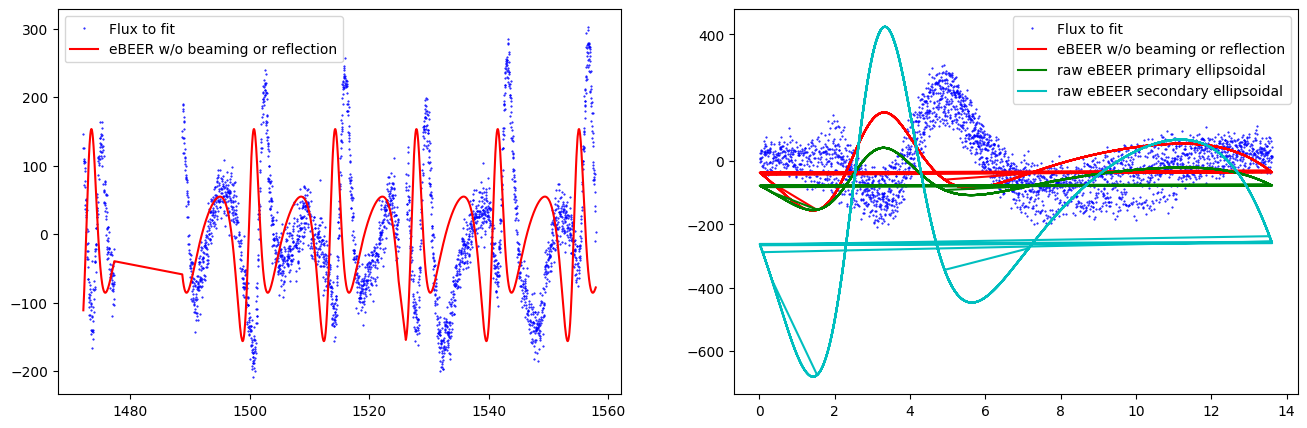

In [62]:
flux_test = fit_ebeer_Kepler(time, 0, 0,0,0,0)
ebeer_primary, ebeer_secondary = get_ebeer_lc(phoebe_binary_, time, 0,0,0,0, 'split')
phase_test = (time) % binary_params.per


plt.figure(figsize=(16,5), label= 'Gauge initial guess for time shift')
plt.subplot(121)
plt.plot(time, detrended_flux, 'b.', markersize= 1, label= 'Flux to fit')
plt.plot(time, flux_test, 'r', label= 'eBEER w/o beaming or reflection')
plt.legend()

plt.subplot(122)
plt.plot(phase_test, detrended_flux, 'b.', markersize= 1, label= 'Flux to fit')
plt.plot(phase_test, flux_test, 'r', label= 'eBEER w/o beaming or reflection')
plt.plot(phase_test, ebeer_primary, 'g', label= 'raw eBEER primary ellipsoidal')
plt.plot(phase_test, ebeer_secondary, 'c', label= 'raw eBEER secondary ellipsoidal')
plt.legend()
print(f'med(eBEER): {np.median(flux_test)}')

Now we can run the fit and view the results

In [63]:
popt_, pcov_ = curve_fit(fit_ebeer_Kepler, time, detrended_flux, 
                         p0= (12.0 / binary_params.per, 0.5, 0.5, 0.5, 0.5), 
                         bounds= ([0, 0, 0, 0, 0], [1, 1, 1, 1, 1]))

In [64]:
fit_params_ = ('Time Shift', 'Alpha Beaming 1', 'Alpha Beaming 2', 
               'Alpha Reflective 1', 'Alpha Reflective 2')
rescaled_ = fit_scaling_Kepler(popt_[0], popt_[1], popt_[2], popt_[3], popt_[4])
for name,value in zip(fit_params_, rescaled_):
    print(name+':', value)

Time Shift: 11.837034325135114
Alpha Beaming 1: 1.1274180738291466
Alpha Beaming 2: 1.9686063070407536
Alpha Reflective 1: 0.005531793105704156
Alpha Reflective 2: 0.09188558501071724


Ellipticity amplitude: 154.92303107042275 (-220.53859838528956 to 89.30746375555594)
Beaming amplitude: 319.66610159512004 (-313.6503442289461 to 325.681858961294)
Reflection amplitude: 292.18456356735885 (-267.31330926568836 to 317.05581786902934)


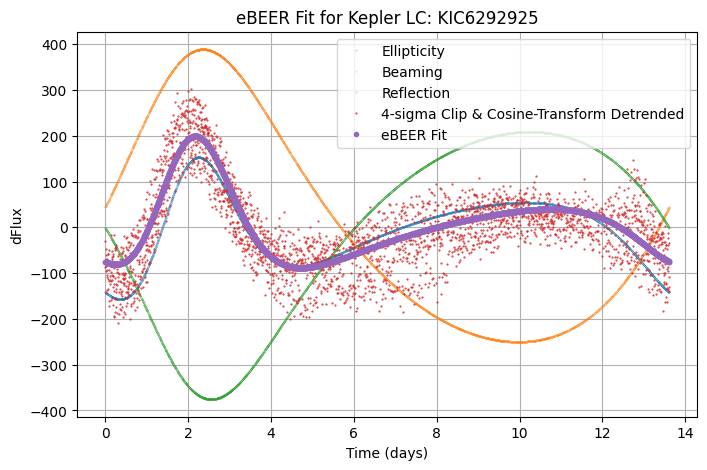

In [75]:
def report_amplitude(flux, label):
    plt.plot(phase, flux - np.median(flux), '.', label=label, markersize=0.3)
    print(f'{label} amplitude: {(flux.max() - flux.min()) / 2} ({flux.min()} to {flux.max()})')

plt.figure(figsize=(8, 5))
plt.grid(True)
fit_flux_ = fit_ebeer_Kepler(time, popt_[0], popt_[1], 
                             popt_[2], popt_[3], popt_[4])

ebeer_coef = fit_scaling_Kepler(*popt_)
flux = get_ebeer_lc(phoebe_binary_, (time + ebeer_coef[0]) % binary_params.per, 0, 0, 0, 0)
report_amplitude(flux, 'Ellipticity')
flux = get_ebeer_lc(phoebe_binary_, 
                    (time + ebeer_coef[0]) % binary_params.per, 
                    ebeer_coef[1], 0, ebeer_coef[3], 0, 
                    disable_ellipticity=True)
report_amplitude(flux, 'Beaming')
flux = get_ebeer_lc(phoebe_binary_, 
                    (time + ebeer_coef[0]) % binary_params.per, 
                    0, ebeer_coef[2], 0, ebeer_coef[4],
                    disable_ellipticity=True)
report_amplitude(flux, 'Reflection')

plt.plot(phase, detrended_flux, '.', markersize=1, label='4-sigma Clip & Cosine-Transform Detrended')
plt.plot(phase, fit_flux_, '.',  label='eBEER Fit')
plt.title(f'eBEER Fit for Kepler LC: {target_name}')
plt.xlabel('Time (days)')
plt.ylabel('dFlux')
plt.legend()



In [44]:
dif = np.abs(fit_flux_ - detrended_flux)
MSD = np.sqrt(np.mean(dif**2))

print(f'Mean Diff: {np.mean(dif)} ppm   STD: {np.std(dif)} ppm')
print(f'MSD: {MSD} ppm')

Mean Diff: 58.773907918291 ppm   STD: 43.458075827158424 ppm
MSD: 73.09566749532287 ppm


# Additional Fit Validation
We can further verify that our model code works by comparing the amplitudes of the individual effects to those reported in Engel et al. 2020.

In [45]:
eBp = phoebe_to_eBEER.eBEERParams(phoebe_binary_, time)
secondary_flux_fraction = (
        phoebe_binary_['secondary@teff'].get_value('K')
        /
        phoebe_binary_['primary@teff'].get_value('K')
    )**4 * (eBp.R2 / eBp.R1)**2

beaming_mod1 = phoebe_to_eBEER.Mbeam(eBp, rescaled_[1])
beaming_mod2 = phoebe_to_eBEER.Mbeam(eBp, rescaled_[2], False)
beaming_tot = (beaming_mod1 + secondary_flux_fraction * beaming_mod2) / (1 + secondary_flux_fraction)

ellip_mod1 = phoebe_to_eBEER.Mellip(eBp)
ellip_mod2 = phoebe_to_eBEER.Mellip(eBp, False)
ellip_tot = (ellip_mod1 + secondary_flux_fraction * ellip_mod2) / (1 + secondary_flux_fraction)

refl_mod1 = phoebe_to_eBEER.Mrefl(eBp, rescaled_[3])
refl_mod2 = phoebe_to_eBEER.Mrefl(eBp, rescaled_[4], False)
refl_tot = (refl_mod1 + secondary_flux_fraction * refl_mod2) / (1 + secondary_flux_fraction)

sum = beaming_tot + ellip_tot + refl_tot


plot_beaming = (beaming_tot/1e6 - np.median(beaming_tot/1e6)) / (1 + np.median(beaming_tot/1e6)) * 1e6
plot_ellip = (ellip_tot/1e6 - np.median(ellip_tot/1e6)) / (1 + np.median(ellip_tot/1e6)) * 1e6
plot_refl = (refl_tot/1e6 - np.median(refl_tot/1e6)) / (1 + np.median(refl_tot/1e6)) * 1e6
plot_sum = (sum/1e6 - np.median(sum/1e6)) / (1 + np.median(sum/1e6)) * 1e6


Abeam = (np.max(plot_beaming) - np.min(plot_beaming))/2
Aellip = (np.max(plot_ellip) - np.min(plot_ellip))/2
Arefl = (np.max(plot_refl) - np.min(plot_refl))/2
print(f'Abeam: {Abeam}, Aellip: {Aellip}, Arefl:{Arefl}')

plt.plot(phase, plot_beaming, label= 'beam')
plt.plot(phase, plot_ellip, label= 'ellip')
plt.plot(phase, plot_refl, label= 'refl')
plt.plot(phase, plot_sum, label= 'sum')
plt.legend()


NameError: name 'phoebe_to_eBEER' is not defined